# Baseline e Thompson Sampling contextual

O experimento compara a regra fixa de não enviar comunicação (`no_email`), escolhida pelo projeto, com Thompson Sampling Beta-Bernoulli. O professor exige uma regra fixa, mas não determina qual. A melhor campanha histórica também é comparada para evitar uma conclusão baseada apenas em um controle conservador.

O treino inicializa os posteriores; a validação seleciona a política; o teste reservado mede o resultado. Nenhuma semente, segmentação ou hiperparâmetro é escolhido com base no teste. A avaliação principal usa o mesmo método estocástico `recommend` da API.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "src/datathon").is_dir()
)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Raiz do projeto localizada.")

Raiz do projeto localizada.


In [2]:
from scripts.build_golden_set import build as build_golden_set
from scripts.build_policy_snapshot import build as build_snapshot
from scripts.run_experiment import run

from datathon.data import load_clean, stratified_split
from datathon.evaluation import sequential_replay
from datathon.policies import ThompsonSamplingPolicy, fit_policy

DATA_PATH = Path("data/raw/hillstrom.csv")
SUMMARY_PATH = Path("artifacts/experiment_summary.json")
FIGURES_PATH = Path("artifacts/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

summary = run(DATA_PATH, SUMMARY_PATH, seed=2026)
build_snapshot(DATA_PATH, SUMMARY_PATH, Path("config/policy_snapshot.json"))
display(pd.DataFrame([summary["rows"]]))
print("Protocolo:", summary["evaluation_protocol"])
print("Semente fixa:", summary["seed"])

,total,train,validation,test
0,64000,38399,12799,12802


Protocolo: stratified-shuffled-replay-v2
Semente fixa: 2026


## Resultado final

`no_email` representa o controle sem comunicação. A melhor ação fixa é escolhida exclusivamente no treino. A estimativa IPS usa a probabilidade de atribuição histórica de 1/3; os intervalos de 95% são aproximações descritivas e não constituem teste formal de superioridade entre políticas adaptativas.

O percentual de exploração é a fração de recomendações diferentes da maior média posterior; Thompson Sampling não recebe um epsilon fixo. O prior por ação/segmento é `Beta(1, 1)`.

In [3]:
comparison = pd.DataFrame(
    [
        {
            "policy": "baseline_no_email",
            "value_ips": summary["baseline_value_ips"],
            "ci_lower": summary["baseline_ci95"][0],
            "ci_upper": summary["baseline_ci95"][1],
        },
        {
            "policy": f"best_fixed_{summary['best_fixed_action']}",
            "value_ips": summary["best_fixed_value_ips"],
            "ci_lower": summary["best_fixed_ci95"][0],
            "ci_upper": summary["best_fixed_ci95"][1],
        },
        {
            "policy": "thompson_sampling",
            "value_ips": summary["thompson_replay_value_ips"],
            "ci_lower": summary["thompson_replay_ci95"][0],
            "ci_upper": summary["thompson_replay_ci95"][1],
        },
    ]
)
comparison["difference_vs_baseline"] = comparison["value_ips"] - summary["baseline_value_ips"]
display(
    comparison.style.format(
        {
            "value_ips": "{:.4%}",
            "ci_lower": "{:.4%}",
            "ci_upper": "{:.4%}",
            "difference_vs_baseline": "{:+.4%}",
        }
    )
)

print(f"Política escolhida na validação: {summary['selected_policy']}")
print(f"Lift de Thompson Sampling contra no_email: {summary['lift_replay']:+.6f}")
print(f"Diferença contra a melhor ação fixa: {summary['lift_replay_vs_best_fixed']:+.6f}")
print(f"Exploração observada: {summary['thompson_exploration_rate']:.2%}")
print(f"Ganho contra controle em pontos percentuais: {100 * summary['lift_replay']:.4f}")

,policy,value_ips,ci_lower,ci_upper,difference_vs_baseline
0,baseline_no_email,0.7030%,0.4517%,0.9543%,+0.0000%
1,best_fixed_mens_email,1.4763%,1.1127%,1.8400%,+0.7733%
2,thompson_sampling,1.5466%,1.1744%,1.9188%,+0.8436%


Política escolhida na validação: thompson_sampling
Lift de Thompson Sampling contra no_email: +0.008436
Diferença contra a melhor ação fixa: +0.000703
Exploração observada: 22.29%
Ganho contra controle em pontos percentuais: 0.8436


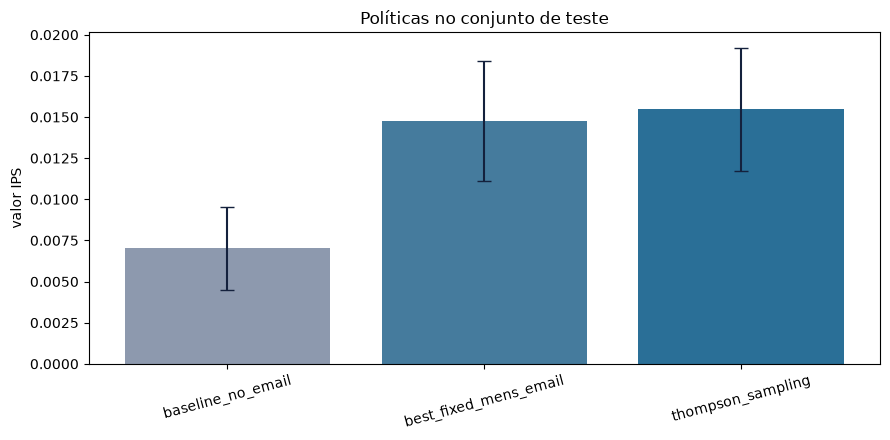

In [4]:
errors = [
    comparison["value_ips"] - comparison["ci_lower"],
    comparison["ci_upper"] - comparison["value_ips"],
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison["policy"], comparison["value_ips"], color=["#8d99ae", "#457b9d", "#2a6f97"])
ax.errorbar(
    comparison["policy"],
    comparison["value_ips"],
    yerr=errors,
    fmt="none",
    ecolor="#14213d",
    capsize=5,
)
ax.set_ylabel("valor IPS")
ax.set_title("Políticas no conjunto de teste")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Comportamento sequencial e ausência de vazamento

O split preserva aproximadamente 60%/20%/20% por ação. Após a separação, cada partição é embaralhada com uma semente determinística. Assim o replay não recebe blocos artificiais de campanhas. A base não contém timestamp: esta sequência simula chegadas randomizadas e não mede drift temporal.

O modelo começa cada avaliação com o estado do treino e só aprende com uma linha de validação/teste depois de recomendá-la, quando a ação coincide com a registrada. Resultados de ações não recebidas são desconhecidos. Apenas o treino compõe o snapshot publicado; o aprendizado durante o replay não é incorporado a ele.

,train,validation,test
action,,,
mens_email,12784,4261,4262
no_email,12783,4261,4262
womens_email,12832,4277,4278


Ações nas primeiras 12 linhas do teste: ['no_email', 'womens_email', 'womens_email', 'no_email', 'mens_email', 'mens_email', 'no_email', 'no_email', 'mens_email', 'mens_email', 'no_email', 'mens_email']


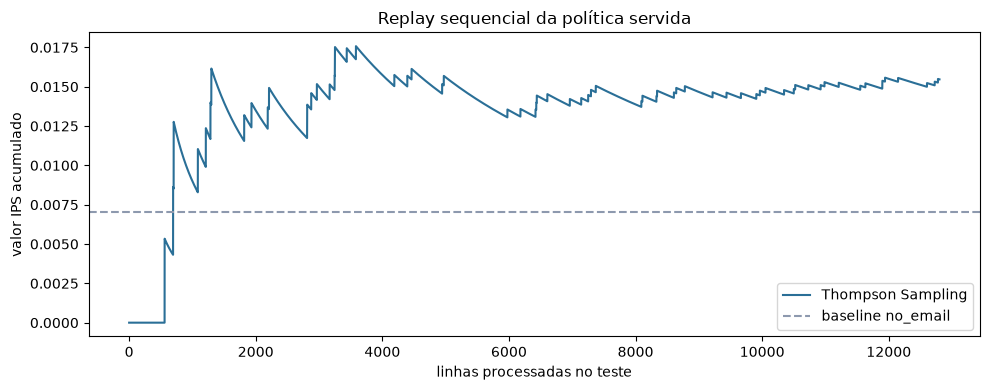

In [5]:
frame = load_clean(DATA_PATH)
train, validation, test = stratified_split(frame, seed=2026)
display(
    pd.DataFrame(
        {
            name: part["action"].value_counts()
            for name, part in [("train", train), ("validation", validation), ("test", test)]
        }
    )
)
print("Ações nas primeiras 12 linhas do teste:", test["action"].head(12).tolist())
replay_policy = ThompsonSamplingPolicy(seed=2026)
fit_policy(replay_policy, train)
replay = sequential_replay(test, replay_policy)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(replay.cumulative_values, color="#2a6f97", linewidth=1.5, label="Thompson Sampling")
ax.axhline(
    summary["baseline_value_ips"], color="#8d99ae", linestyle="--", label="baseline no_email"
)
ax.set_xlabel("linhas processadas no teste")
ax.set_ylabel("valor IPS acumulado")
ax.set_title("Replay sequencial da política servida")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_PATH / "sequential_replay.png", dpi=160, bbox_inches="tight")
plt.show()

## Golden Set: cinco entradas e análise das recomendações

Os payloads abaixo são fictícios e fixos. Cada caso possui segmento esperado e justificativa definidos separadamente da resposta do modelo. O resultado é reprovado se a ação não pertence ao catálogo, o segmento diverge, falta evidência treinada, as probabilidades são inválidas ou a explicação de exploração contradiz a amostragem.

A checagem complementa a leitura qualitativa e não comprova resultado comercial. Uma refatoração deve continuar retornando recomendações coerentes; não se exige que uma política estocástica escolha sempre a mesma oferta. Os testes unitários do código são uma evidência distinta.

In [6]:
golden_rows = build_golden_set(Path("config/policy_snapshot.json"))
display(pd.DataFrame([{"case_id": row["case_id"], **row["context"]} for row in golden_rows]))
golden_table = pd.DataFrame(
    [
        {
            "case_id": row["case_id"],
            "segment": row["segment"],
            "expected_segment": row["expected_segment"],
            "recommended_action": row["recommended_action"],
            "exploration": row["exploration"],
            "decision_makes_sense": row["decision_makes_sense"],
            "rationale": row["rationale"],
        }
        for row in golden_rows
    ]
)
with pd.option_context("display.max_colwidth", None):
    display(golden_table)
display(pd.DataFrame([{"case_id": row["case_id"], **row["checks"]} for row in golden_rows]))

,case_id,recency,history,mens,womens,newbie,zip_code,channel
0,recent_mens_web,2,420.0,1,0,0,Urban,Web
1,recent_womens_multichannel,3,610.0,0,1,0,Surburban,Multichannel
2,middle_mixed_web,5,780.0,1,1,0,Urban,Web
3,old_mens_phone,9,260.0,1,0,1,Rural,Phone
4,old_womens_web,11,330.0,0,1,1,Urban,Web


,case_id,segment,expected_segment,recommended_action,exploration,decision_makes_sense,rationale
0,recent_mens_web,recent:mens,recent:mens,mens_email,False,True,"Compra recente na categoria masculina; comparar as campanhas nesse segmento, sem inferir gênero. A decisão é coerente como aproveitamento: a ação escolhida também possui a maior média posterior neste segmento. A evidência vem do experimento randomizado do benchmark e não substitui validação própria ou revisão humana em um produto financeiro."
1,recent_womens_multichannel,recent:womens,recent:womens,mens_email,False,True,Afinidade feminina recente não obriga campanha feminina; a resposta experimental e sua incerteza orientam a escolha. A decisão é coerente como aproveitamento: a ação escolhida também possui a maior média posterior neste segmento. A evidência vem do experimento randomizado do benchmark e não substitui validação própria ou revisão humana em um produto financeiro.
2,middle_mixed_web,middle:mixed,middle:mixed,mens_email,False,True,"Compras nas duas categorias e recência intermediária exigem o segmento misto, sem escolher por um rótulo demográfico. A decisão é coerente como aproveitamento: a ação escolhida também possui a maior média posterior neste segmento. A evidência vem do experimento randomizado do benchmark e não substitui validação própria ou revisão humana em um produto financeiro."
3,old_mens_phone,old:mens,old:mens,mens_email,False,True,Recência antiga deve usar o segmento antigo; o canal Phone é histórico e não altera a campanha de e-mail avaliada. A decisão é coerente como aproveitamento: a ação escolhida também possui a maior média posterior neste segmento. A evidência vem do experimento randomizado do benchmark e não substitui validação própria ou revisão humana em um produto financeiro.
4,old_womens_web,old:womens,old:womens,mens_email,False,True,Histórico feminino antigo não impõe gênero nem elegibilidade; qualquer ação do catálogo precisa respeitar a amostragem. A decisão é coerente como aproveitamento: a ação escolhida também possui a maior média posterior neste segmento. A evidência vem do experimento randomizado do benchmark e não substitui validação própria ou revisão humana em um produto financeiro.


,case_id,catalog_action,expected_segment,trained_segment,valid_posterior_means,valid_samples,sampling_consistency,exploration_consistency
0,recent_mens_web,True,True,True,True,True,True,True
1,recent_womens_multichannel,True,True,True,True,True,True,True
2,middle_mixed_web,True,True,True,True,True,True,True
3,old_mens_phone,True,True,True,True,True,True,True
4,old_womens_web,True,True,True,True,True,True,True


## Interpretação e limites

Com o protocolo corrigido e a semente previamente fixada em `2026`, Thompson Sampling apresenta ganho pontual contra o controle sem comunicação e uma diferença pequena contra a melhor campanha fixa histórica. Os intervalos de Thompson Sampling e da melhor ação fixa se sobrepõem. O resultado não comprova superioridade estatística nem garante ganho futuro.

A estimativa descreve conversão de campanhas de varejo. Não mede aprovação de crédito, receita bancária ou comportamento de clientes de banco. A versão anterior do replay ordenava as ações em blocos; seus números foram substituídos, sem alterar semente ou algoritmo para maximizar o teste. O benefício demonstrado é a capacidade de atualizar a escolha com feedback e manter rastreabilidade, não uma promessa de vencer toda regra fixa.